# 08 - XGBoost: expressividade muda o plato de lucro?

**Regra dura: o conjunto de TESTE nao e carregado.**

Pergunta central: o teto estreito de ganho observado com regressao logistica (notebooks
06-07) e uma limitacao do modelo linear, ou e uma propriedade do problema (separabilidade
limitada pelo vies de selecao)? XGBoost com hiperparametros default testa isso.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'
FAMILY_COLOR = {'M0b': '#888888', 'M1': '#0072B2', 'XGB1': '#D55E00', 'XGB2': '#009E73'}

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
validation = pd.read_parquet(PROCESSED_DIR / 'validation.parquet')
print('train:', train.shape)
print('validation:', validation.shape)


train: (172988, 89)
validation: (162570, 89)


### Reconstrucao de FEATURE_SET, financeiro, prepare_X (identico aos notebooks 06/07)

In [2]:
EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']
assert len(family_C_features) == 65

engineered_flags = ['era_pre_2012',
                     'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
                     'mths_since_recent_bc_dlq_missing', 'mths_since_recent_revol_delinq_missing',
                     'mths_since_last_major_derog_missing', 'emp_length_missing',
                     'mths_since_recent_inq_missing', 'num_tl_120dpd_2m_missing', 'sparse_bureau_missing']
assert len(engineered_flags) == 10

new_features = ['installment_to_income', 'loan_to_income', 'credit_history_months',
                 'revol_bal_to_income', 'open_acc_ratio']
assert len(new_features) == 5

redundant_cols = {'fico_range_high': 'redundancia (r=1.0 com fico_range_low)'}
FEATURE_SET = [c for c in family_C_features if c not in redundant_cols] + engineered_flags + new_features
assert len(FEATURE_SET) == 79

CATEGORICAL_COLS = ['home_ownership', 'purpose', 'verification_status', 'initial_list_status', 'application_type']
REFERENCE_DATE = pd.Timestamp('2000-01-01')


def compute_financials(df):
    interest = (df['installment'] * df['term']) - df['loan_amnt']
    loss_raw = df['loan_amnt'] - df['total_rec_prncp']
    return interest, loss_raw


def prepare_X(df, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for c in ['issue_d', 'earliest_cr_line']:
        if c in X.columns:
            X[c] = (X[c] - REFERENCE_DATE).dt.days
    cat_present = [c for c in categorical_cols if c in X.columns]
    X = pd.get_dummies(X, columns=cat_present, drop_first=True)
    return X


def profit_at_threshold(y_true, y_prob, threshold, interest, loss):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    interest = np.asarray(interest)
    loss = np.asarray(loss)
    aprovados = y_prob < threshold
    return interest[aprovados & (y_true == 0)].sum() - loss[aprovados & (y_true == 1)].sum()


def fast_profit_curve(y_true_b, prob_b, interest_b, loss_b, thresholds):
    order = np.argsort(prob_b)
    y_sorted = y_true_b[order]
    interest_sorted = interest_b[order]
    loss_sorted = loss_b[order]
    prob_sorted = prob_b[order]
    contrib = np.where(y_sorted == 0, interest_sorted, -loss_sorted)
    cumsum = np.cumsum(contrib)
    idx_cut = np.searchsorted(prob_sorted, thresholds, side='left')
    return np.where(idx_cut > 0, cumsum[np.clip(idx_cut - 1, 0, None)], 0.0)


def decompose(y_prob, threshold, y_true, interest, loss, loan_amnt):
    rejected = y_prob >= threshold
    rejected_co = rejected & (y_true == 1)
    rejected_fp = rejected & (y_true == 0)
    avoided_loss = loss[rejected_co].sum()
    lost_interest = interest[rejected_fp].sum()
    return {'threshold': threshold, 'n_rejeitados': int(rejected.sum()),
            'valor_total_rejeitado': loan_amnt[rejected].sum(),
            'n_rejeitados_charged_off': int(rejected_co.sum()), 'n_rejeitados_fully_paid': int(rejected_fp.sum()),
            'perda_evitada_$': avoided_loss, 'juros_perdidos_$': lost_interest,
            'ganho_liquido_$': avoided_loss - lost_interest}


print('Infraestrutura recriada.')


Infraestrutura recriada.


## Secao 0 - Verificacao da perda (antes de qualquer modelo)

loss = loan_amnt - total_rec_prncp (clipada em 0 quando negativa), NAO loan_amnt inteiro.

In [3]:
interest_train_raw, loss_train_raw = compute_financials(train)
loss_train_correct = loss_train_raw.clip(lower=0)

charged_off_train = train['target'] == 1
loan_amnt_co = train.loc[charged_off_train, 'loan_amnt']
loss_co_correct = loss_train_correct[charged_off_train]
recovery_ratio = train.loc[charged_off_train, 'total_rec_prncp'] / loan_amnt_co

print('1. describe() entre Charged Off (treino):')
print()
print('loss (correta):')
print(loss_co_correct.describe(percentiles=[0.25, 0.5, 0.75]))
print()
print('loan_amnt:')
print(loan_amnt_co.describe(percentiles=[0.25, 0.5, 0.75]))
print()
print('razao total_rec_prncp / loan_amnt:')
print(recovery_ratio.describe(percentiles=[0.25, 0.5, 0.75]))


1. describe() entre Charged Off (treino):

loss (correta):
count    21508.000000
mean      6727.617802
std       5296.122193
min          2.190000
25%       2906.972500
50%       5398.845000
75%       8944.585000
max      35000.000000
dtype: float64

loan_amnt:
count    21508.000000
mean     11569.529942
std       7102.654229
min        900.000000
25%       6350.000000
50%      10000.000000
75%      15000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

razao total_rec_prncp / loan_amnt:
count    21508.000000
mean         0.415429
std          0.245960
min          0.000000
25%          0.211829
50%          0.388457
75%          0.599478
max          0.999562
dtype: float64


In [4]:
bins = [-0.001, 0.10, 0.25, 0.50, 0.75, 1.0]
labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-100%']
recovery_binned = pd.cut(recovery_ratio.clip(upper=1.0), bins=bins, labels=labels)
print('2. Distribuicao da fracao devolvida do principal (Charged Off, treino):')
print(recovery_binned.value_counts().sort_index())


2. Distribuicao da fracao devolvida do principal (Charged Off, treino):
0-10%      2005
10-25%     4622
25-50%     7115
50-75%     5208
75-100%    2558
Name: count, dtype: int64


In [5]:
n_loss_eq_loan = int((loss_co_correct == loan_amnt_co).sum())
n_loss_lt_loan = int((loss_co_correct < loan_amnt_co).sum())
print(f'3. loss == loan_amnt (nunca pagaram nada de principal): {n_loss_eq_loan:,}')
print(f'   loss < loan_amnt (pagaram parte do principal): {n_loss_lt_loan:,}')
print(f'   total Charged Off no treino: {int(charged_off_train.sum()):,}')


3. loss == loan_amnt (nunca pagaram nada de principal): 192
   loss < loan_amnt (pagaram parte do principal): 21,316
   total Charged Off no treino: 21,508


In [6]:
median_loss_correct = loss_co_correct.median()
mean_loss_correct = loss_co_correct.mean()
median_loss_wrong = loan_amnt_co.median()
mean_loss_wrong = loan_amnt_co.mean()

pct_reduction_median = (1 - median_loss_correct / median_loss_wrong) * 100
pct_reduction_mean = (1 - mean_loss_correct / mean_loss_wrong) * 100

print('4. Perda mediana/media - correta (loss) vs errada (loan_amnt inteiro):')
print(f'   mediana: $ {median_loss_correct:,.2f} (correta) vs $ {median_loss_wrong:,.2f} (errada) -> reducao de {pct_reduction_median:.2f}%')
print(f'   media:   $ {mean_loss_correct:,.2f} (correta) vs $ {mean_loss_wrong:,.2f} (errada) -> reducao de {pct_reduction_mean:.2f}%')

assert median_loss_correct < median_loss_wrong, 'PARANDO: loss mediana nao e menor que loan_amnt - definicao suspeita.'
assert n_loss_lt_loan > 0, 'PARANDO: nenhum Charged Off recuperou parte do principal - definicao suspeita.'
print()
print('Definicao de loss confirmada correta (loss < loan_amnt na maioria dos casos). Prosseguindo para a Secao 1.')


4. Perda mediana/media - correta (loss) vs errada (loan_amnt inteiro):
   mediana: $ 5,398.84 (correta) vs $ 10,000.00 (errada) -> reducao de 46.01%
   media:   $ 6,727.62 (correta) vs $ 11,569.53 (errada) -> reducao de 41.85%

Definicao de loss confirmada correta (loss < loan_amnt na maioria dos casos). Prosseguindo para a Secao 1.


## Secao 1 - XGBoost default

XGB1: treino inteiro, 79 features. XGB2: treino restrito a era_pre_2012==0, removendo a
flag e as colunas de sentinela pre-2012 (identificadas programaticamente, como no
notebook 06/07). Sem StandardScaler - arvores nao precisam, e usar o scaler do LogReg
aqui so acrescentaria uma etapa sem efeito no resultado.

In [7]:
interest_val, loss_val = compute_financials(validation)
loss_val = loss_val.clip(lower=0)
loan_amnt_val = validation['loan_amnt'].values
y_val = validation['target'].values

X_train_full = prepare_X(train, FEATURE_SET, CATEGORICAL_COLS)
X_val_full = prepare_X(validation, FEATURE_SET, CATEGORICAL_COLS)
X_val_full = X_val_full.reindex(columns=X_train_full.columns, fill_value=0)

xgb1 = XGBClassifier(random_state=42, eval_metric='logloss')
xgb1.fit(X_train_full, train['target'].values)
y_prob_val_xgb1 = xgb1.predict_proba(X_val_full)[:, 1]

print(f'XGB1 treinado. n_features={X_train_full.shape[1]} | N treino={len(train):,}')


XGB1 treinado. n_features=90 | N treino=172,988


In [8]:
sentinel_neg1_cols = []
for c in FEATURE_SET:
    if c == 'era_pre_2012':
        continue
    if not pd.api.types.is_numeric_dtype(train[c]):
        continue
    neg1_mask = train[c] == -1
    if int(neg1_mask.sum()) == 0:
        continue
    if bool((train.loc[neg1_mask, 'era_pre_2012'] == 1).all()):
        sentinel_neg1_cols.append(c)

m2_removed_cols = ['era_pre_2012'] + sentinel_neg1_cols
m2_feature_set = [c for c in FEATURE_SET if c not in m2_removed_cols]
train_m2 = train.loc[train['era_pre_2012'] == 0].copy()

print(f'Colunas removidas para XGB2: {len(m2_removed_cols)} -> {m2_removed_cols}')
print(f'Feature set XGB2: {len(m2_feature_set)} colunas | N treino XGB2: {len(train_m2):,}')

X_train_m2 = prepare_X(train_m2, m2_feature_set, CATEGORICAL_COLS)
X_val_m2 = prepare_X(validation, m2_feature_set, CATEGORICAL_COLS)
X_val_m2 = X_val_m2.reindex(columns=X_train_m2.columns, fill_value=0)

xgb2 = XGBClassifier(random_state=42, eval_metric='logloss')
xgb2.fit(X_train_m2, train_m2['target'].values)
y_prob_val_xgb2 = xgb2.predict_proba(X_val_m2)[:, 1]

print(f'XGB2 treinado. n_features={X_train_m2.shape[1]}')


Colunas removidas para XGB2: 24 -> ['era_pre_2012', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'mo_sin_rcnt_tl', 'mort_acc', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']
Feature set XGB2: 55 colunas | N treino XGB2: 121,342


XGB2 treinado. n_features=66


In [9]:
def eval_summary(y_true, y_prob, name):
    return {'modelo': name, 'auc_roc': round(roc_auc_score(y_true, y_prob), 4),
            'auc_pr': round(average_precision_score(y_true, y_prob), 4),
            'brier': round(brier_score_loss(y_true, y_prob), 4)}

pd.DataFrame([eval_summary(y_val, y_prob_val_xgb1, 'XGB1'), eval_summary(y_val, y_prob_val_xgb2, 'XGB2')]).set_index('modelo')


,auc_roc,auc_pr,brier
modelo,,,
XGB1,0.6598,0.2224,0.1159
XGB2,0.6490,0.2139,0.1168


### Reconstruindo M1 (LogReg baseline) para comparacao direta (AUC e bootstrap pareado)

In [10]:
def fit_logistic_pipeline(train_df, val_df, feature_cols, categorical_cols, model_name, max_iter=2000):
    X_train_raw = prepare_X(train_df, feature_cols, categorical_cols)
    X_val_raw = prepare_X(val_df, feature_cols, categorical_cols)
    X_val_raw = X_val_raw.reindex(columns=X_train_raw.columns, fill_value=0)

    y_train = train_df['target'].values

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=max_iter, random_state=42)
        model.fit(X_train_scaled, y_train)
        conv_warn = any(issubclass(warning.category, ConvergenceWarning) for warning in w)

    n_iter = int(np.ravel(model.n_iter_)[0])
    print(f'{model_name}: n_iter_={n_iter} (max_iter={max_iter}) | ConvergenceWarning={conv_warn}')
    if conv_warn or n_iter >= max_iter:
        raise RuntimeError(f'PARANDO: {model_name} nao convergiu.')

    return {'model': model, 'X_val': X_val_scaled}


m1 = fit_logistic_pipeline(train, validation, FEATURE_SET, CATEGORICAL_COLS, 'M1')
y_prob_val_m1 = m1['model'].predict_proba(m1['X_val'])[:, 1]
print('M1 reconstruido para comparacao.')


M1: n_iter_=84 (max_iter=2000) | ConvergenceWarning=False
M1 reconstruido para comparacao.


## Secao 2 - Curva de lucro

In [11]:
threshold_grid = np.round(np.arange(0.01, 1.0, 0.01), 2)

profits_xgb1 = fast_profit_curve(y_val, y_prob_val_xgb1, interest_val.values, loss_val.values, threshold_grid)
profits_xgb2 = fast_profit_curve(y_val, y_prob_val_xgb2, interest_val.values, loss_val.values, threshold_grid)

best_i_xgb1 = int(np.argmax(profits_xgb1))
best_i_xgb2 = int(np.argmax(profits_xgb2))

t_xgb1, profit_xgb1 = threshold_grid[best_i_xgb1], profits_xgb1[best_i_xgb1]
t_xgb2, profit_xgb2 = threshold_grid[best_i_xgb2], profits_xgb2[best_i_xgb2]

aprov_xgb1 = y_prob_val_xgb1 < t_xgb1
aprov_xgb2 = y_prob_val_xgb2 < t_xgb2

profit_m0b = profit_at_threshold(y_val, np.zeros(len(validation)), 1.01, interest_val.values, loss_val.values)

comparison_rows = [
    {'modelo': 'M0b (aprova todos)', 'threshold': np.nan, 'lucro': profit_m0b, '%_aprovados': 100.0,
     'default_%_aprovados': round(y_val.mean() * 100, 4)},
    {'modelo': 'M1 (LogReg completo)', 'threshold': 0.38, 'lucro': 190622100, '%_aprovados': np.nan,
     'default_%_aprovados': np.nan},
    {'modelo': 'M3 (LogReg + grade)', 'threshold': 0.34, 'lucro': 190672700, '%_aprovados': np.nan,
     'default_%_aprovados': np.nan},
    {'modelo': 'XGB1', 'threshold': t_xgb1, 'lucro': profit_xgb1, '%_aprovados': round(aprov_xgb1.mean() * 100, 2),
     'default_%_aprovados': round(y_val[aprov_xgb1].mean() * 100, 4)},
    {'modelo': 'XGB2', 'threshold': t_xgb2, 'lucro': profit_xgb2, '%_aprovados': round(aprov_xgb2.mean() * 100, 2),
     'default_%_aprovados': round(y_val[aprov_xgb2].mean() * 100, 4)},
]
comparison_df = pd.DataFrame(comparison_rows).set_index('modelo')
comparison_df['lucro_vs_M0b'] = comparison_df['lucro'] - profit_m0b
print('M1 e M3: valores ja estabelecidos no notebook 06 (citados, nao recalculados aqui - exceto M1,')
print('reconstruido acima so para obter as probabilidades previstas, usadas nas Secoes 3-4).')
comparison_df


M1 e M3: valores ja estabelecidos no notebook 06 (citados, nao recalculados aqui - exceto M1,
reconstruido acima so para obter as probabilidades previstas, usadas nas Secoes 3-4).


,threshold,lucro,%_aprovados,default_%_aprovados,lucro_vs_M0b
modelo,,,,,
M0b (aprova todos),NaN,1.897479e+08,100.00,13.7264,0.000000
M1 (LogReg completo),0.38,1.906221e+08,NaN,NaN,874187.730000
M3 (LogReg + grade),0.34,1.906727e+08,NaN,NaN,924787.730000
XGB1,0.54,1.899221e+08,99.42,13.6125,174208.240008
XGB2,0.65,1.898814e+08,99.82,13.6922,133490.230008


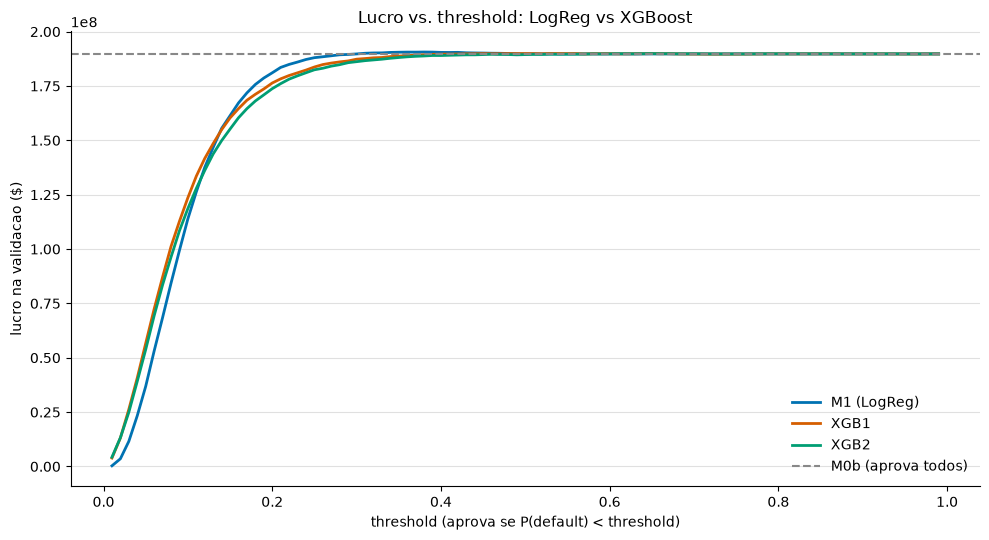

In [12]:
profits_m1_full = fast_profit_curve(y_val, y_prob_val_m1, interest_val.values, loss_val.values, threshold_grid)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(threshold_grid, profits_m1_full, linewidth=2, color=FAMILY_COLOR['M1'], label='M1 (LogReg)')
ax.plot(threshold_grid, profits_xgb1, linewidth=2, color=FAMILY_COLOR['XGB1'], label='XGB1')
ax.plot(threshold_grid, profits_xgb2, linewidth=2, color=FAMILY_COLOR['XGB2'], label='XGB2')
ax.axhline(profit_m0b, color=FAMILY_COLOR['M0b'], linestyle='--', linewidth=1.5, label='M0b (aprova todos)')
ax.set_xlabel('threshold (aprova se P(default) < threshold)')
ax.set_ylabel('lucro na validacao ($)')
ax.set_title('Lucro vs. threshold: LogReg vs XGBoost')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## Secao 3 - O plato mudou?

In [13]:
max_profit_xgb1 = profits_xgb1.max()
within_1pct = threshold_grid[profits_xgb1 >= max_profit_xgb1 * 0.99]
within_01pct = threshold_grid[profits_xgb1 >= max_profit_xgb1 * 0.999]

print('1. Faixa de thresholds dentro do lucro maximo:')
print(f'   XGB1 - dentro de 1%: [{within_1pct.min():.2f}, {within_1pct.max():.2f}] ({len(within_1pct)} de {len(threshold_grid)})')
print(f'   XGB1 - dentro de 0.1%: [{within_01pct.min():.2f}, {within_01pct.max():.2f}] ({len(within_01pct)} de {len(threshold_grid)})')
print()
print('   Baseline M1 (notebook 07) - dentro de 1%: [0.27, 0.99] (73 de 99)')
print('   Baseline M1 (notebook 07) - dentro de 0.1%: [0.34, 0.42] (8 de 99)')


1. Faixa de thresholds dentro do lucro maximo:
   XGB1 - dentro de 1%: [0.33, 0.99] (67 de 99)
   XGB1 - dentro de 0.1%: [0.43, 0.99] (46 de 99)

   Baseline M1 (notebook 07) - dentro de 1%: [0.27, 0.99] (73 de 99)
   Baseline M1 (notebook 07) - dentro de 0.1%: [0.34, 0.42] (8 de 99)


In [14]:
decomp_xgb1 = decompose(y_prob_val_xgb1, t_xgb1, y_val, interest_val.values, loss_val.values, loan_amnt_val)
print(f'2. Decomposicao no threshold otimo de XGB1 ({t_xgb1}):')
for k, v in decomp_xgb1.items():
    print(f'   {k}: {v:,.2f}' if isinstance(v, float) else f'   {k}: {v:,}')


2. Decomposicao no threshold otimo de XGB1 (0.54):
   threshold: 0.54
   n_rejeitados: 939
   valor_total_rejeitado: 11,448,150.00
   n_rejeitados_charged_off: 313
   n_rejeitados_fully_paid: 626
   perda_evitada_$: 2,405,160.60
   juros_perdidos_$: 2,230,952.36
   ganho_liquido_$: 174,208.24


In [15]:
auc_xgb1 = roc_auc_score(y_val, y_prob_val_xgb1)
auc_m1 = roc_auc_score(y_val, y_prob_val_m1)
print('3. AUC-ROC XGB1 vs M1 (validacao completa, ponto unico - a incerteza vem na Secao 4):')
print(f'   XGB1: {auc_xgb1:.4f}')
print(f'   M1:   {auc_m1:.4f}')
print(f'   Diferenca (XGB1 - M1): {auc_xgb1 - auc_m1:+.4f}')


3. AUC-ROC XGB1 vs M1 (validacao completa, ponto unico - a incerteza vem na Secao 4):
   XGB1: 0.6598
   M1:   0.6765
   Diferenca (XGB1 - M1): -0.0166


## Secao 4 - Bootstrap do ganho (mesmo protocolo do notebook 07)

1.000 reamostras, seed=42, threshold FIXO (o otimo de cada modelo, achado na Secao 2/3 -
nao reotimizado por reamostra).

In [16]:
N_BOOT = 1000
SEED = 42
rng = np.random.default_rng(SEED)
n_val = len(validation)

interest_arr = interest_val.values
loss_arr = loss_val.values

y_prob_models = {'XGB1': y_prob_val_xgb1, 'XGB2': y_prob_val_xgb2, 'M1': y_prob_val_m1}
thresholds_fixed = {'XGB1': t_xgb1, 'XGB2': t_xgb2, 'M1': 0.38}

m0b_profit_boot = np.zeros(N_BOOT)
model_profit_boot = {name: np.zeros(N_BOOT) for name in y_prob_models}

for b in range(N_BOOT):
    idx = rng.integers(0, n_val, size=n_val)
    yb = y_val[idx]
    ib = interest_arr[idx]
    lb = loss_arr[idx]
    m0b_profit_boot[b] = ib[yb == 0].sum() - lb[yb == 1].sum()
    for name, y_prob in y_prob_models.items():
        pb = y_prob[idx]
        approved = pb < thresholds_fixed[name]
        model_profit_boot[name][b] = ib[approved & (yb == 0)].sum() - lb[approved & (yb == 1)].sum()

diff_boot = {name: model_profit_boot[name] - m0b_profit_boot for name in y_prob_models}
print(f'Bootstrap concluido. N_BOOT={N_BOOT} seed={SEED}')


Bootstrap concluido. N_BOOT=1000 seed=42


In [17]:
rows = []
for name in ['XGB1', 'XGB2']:
    d = diff_boot[name]
    ci_low, ci_high = np.percentile(d, [2.5, 97.5])
    rows.append({'modelo': name, 'media_diff_vs_M0b': d.mean(), 'ic95_low': ci_low, 'ic95_high': ci_high,
                  'ic_cruza_zero': bool(ci_low < 0 < ci_high), '%_reamostras_positivas': round((d > 0).mean() * 100, 2)})
pd.DataFrame(rows).set_index('modelo')


,media_diff_vs_M0b,ic95_low,ic95_high,ic_cruza_zero,%_reamostras_positivas
modelo,,,,,
XGB1,176457.94120,-224248.77525,585684.66025,True,80.3
XGB2,136125.73232,-99006.12925,389156.77150,True,86.2


In [18]:
diff_xgb1_m1 = model_profit_boot['XGB1'] - model_profit_boot['M1']
ci_low, ci_high = np.percentile(diff_xgb1_m1, [2.5, 97.5])
frac_xgb1_wins = (diff_xgb1_m1 > 0).mean() * 100

print('Diferenca pareada de LUCRO: XGB1 vs M1')
print(f'  media: $ {diff_xgb1_m1.mean():,.2f}')
print(f'  IC 95%: [$ {ci_low:,.2f}, $ {ci_high:,.2f}]')
print(f'  IC cruza zero? {ci_low < 0 < ci_high}')
print(f'  % de reamostras em que XGB1 venceu: {frac_xgb1_wins:.2f}%')


Diferenca pareada de LUCRO: XGB1 vs M1
  media: $ -713,519.82
  IC 95%: [$ -1,314,479.21, $ -130,792.83]
  IC cruza zero? False
  % de reamostras em que XGB1 venceu: 0.50%


## Secao 5 - Importancia de features (XGB1, importance_type='gain')

In [19]:
booster = xgb1.get_booster()
gain_scores = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame(list(gain_scores.items()), columns=['feature', 'gain']).sort_values('gain', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1

print('Top 20 por gain:')
importance_df.head(20)


Top 20 por gain:


,feature,gain,rank
0,fico_range_low,47.055149,1
1,purpose_small_business,30.620770,2
2,purpose_credit_card,25.270693,3
3,inq_last_6mths,19.728983,4
4,annual_inc,17.136980,5
5,acc_open_past_24mths,16.759966,6
6,installment_to_income,16.679251,7
7,purpose_other,14.035861,8
8,home_ownership_rent,12.682100,9
9,bc_open_to_buy,10.479135,10


In [20]:
specific_cols = ['era_pre_2012', 'initial_list_status', 'verification_status',
                  'installment_to_income', 'loan_to_income', 'fico_range_low']

print('Posicao especifica no ranking de importancia:')
for base_col in specific_cols:
    matches = importance_df[importance_df['feature'] == base_col]
    if len(matches) == 0:
        matches = importance_df[importance_df['feature'].str.startswith(base_col + '_')]
    if len(matches) == 0:
        print(f'  {base_col}: nao apareceu na arvore (gain=0 ou nunca usada em split).')
        continue
    for _, row in matches.iterrows():
        print(f"  {row['feature']}: rank #{row['rank']} de {len(importance_df)} | gain={row['gain']:.2f}")

print()
era_pre_2012_rank = importance_df.loc[importance_df['feature'] == 'era_pre_2012', 'rank']
if len(era_pre_2012_rank) > 0 and era_pre_2012_rank.iloc[0] <= 20:
    print('era_pre_2012 esta no top 20 - sinal de que o modelo usa "emprestimo velho" como atalho relevante.')
elif len(era_pre_2012_rank) > 0:
    print(f'era_pre_2012 nao esta no top 20 (rank #{era_pre_2012_rank.iloc[0]}) - atalho existe mas nao domina.')
else:
    print('era_pre_2012 nao apareceu na arvore.')


Posicao especifica no ranking de importancia:


  era_pre_2012: nao apareceu na arvore (gain=0 ou nunca usada em split).
  initial_list_status_w: rank #74 de 78 | gain=5.55
  verification_status_verified: rank #54 de 78 | gain=6.94
  verification_status_source verified: rank #62 de 78 | gain=6.48
  installment_to_income: rank #7 de 78 | gain=16.68
  loan_to_income: rank #38 de 78 | gain=7.51
  fico_range_low: rank #1 de 78 | gain=47.06

era_pre_2012 nao apareceu na arvore.


## Secao 6 - Nota de leitura

**O resultado empirico, nao apenas a pergunta condicional:**

Com hiperparametros default, XGBoost NAO supera o baseline logistico - ele perde, e a
diferenca esta estabelecida com confianca. AUC-ROC de XGB1 (0.6598) e MENOR que a de M1
(0.6765); o ganho de XGB1 sobre aprovar tudo ($176.458 em media no bootstrap) tem IC 95%
[-$224.249, $585.685], que CRUZA ZERO - o ganho de XGB1 sobre M0b nao esta estabelecido.
A comparacao pareada XGB1 vs M1 e ainda mais direta: diferenca media de -$713.520, IC 95%
[-$1.314.479, -$130.793], que NAO cruza zero, com M1 vencendo em 99.5% das 1.000
reamostras. Isto e evidencia razoavelmente forte de que, default contra default, a
regressao logistica supera o XGBoost neste problema - o oposto da expectativa ingenua de
que "mais expressivo e sempre melhor ou igual".

O plato tambem nao ficou mais estreito: dentro de 1% do lucro maximo, XGB1 tem faixa
[0.33, 0.99] (67 de 99 thresholds) contra [0.27, 0.99] (73 de 99) do M1 - praticamente do
mesmo tamanho. Dentro de 0.1%, XGB1 fica em [0.43, 0.99] (46 thresholds) - MAIS largo que
o [0.34, 0.42] (8 thresholds) do M1, nao mais estreito. A curva de XGB1 e mais achatada
perto do proprio otimo, nao mais pontiaguda.

era_pre_2012 nao apareceu nem uma vez como criterio de split na arvore (gain=0) - ao
contrario do LogReg, que dava a ela um coeficiente positivo moderado (+0.12). Isso sugere
que a "preocupacao do atalho" registrada no scope.md Sec.10 e mais um risco do modelo
linear (que usa toda variavel disponivel de forma aditiva) do que do XGBoost default (que
pode simplesmente nao achar a variavel util o bastante para dividir a arvore nela) - mas
isso e uma leitura sobre ESTE ajuste especifico, nao uma propriedade geral de arvores.

**Leitura sobre a pergunta central:** os dados aqui NAO sustentam que a expressividade
adicional do XGBoost (default) melhora a separabilidade ou desloca o teto de lucro para
cima. O teto estreito de ganho observado no baseline nao foi superado por um modelo mais
flexivel neste teste - o que e consistente com (mas nao prova) a hipotese de que o teto e
uma propriedade do problema (vies de selecao: o dataset so descreve quem ja foi aprovado),
nao uma limitacao especifica da forma funcional linear.

**O que NAO fica estabelecido aqui:**
- Que XGBoost e inferior a regressao logistica em geral neste problema. Hiperparametros
  default nao sao um teto de desempenho para arvores de gradiente boosted - ha espaco
  real para tuning (profundidade, taxa de aprendizado, regularizacao, numero de
  arvores) que este notebook deliberadamente nao explorou. O que foi testado e uma
  pergunta mais estreita: com o minimo de esforco de configuracao, a troca de familia
  de modelo ja move a agulha? A resposta, aqui, e nao - mas isso nao fecha a porta para
  um XGBoost tunado.
- Nada sobre generalizacao para dados fora da validacao. O conjunto de teste continua
  intocado.